In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize


def prepare_returns(path):
    data = pd.read_csv(path)
    data["MthCalDt"] = pd.to_datetime(data["MthCalDt"])
    data = data.sort_values(["Ticker", "MthCalDt"])
    data = data.groupby(["Ticker", "MthCalDt"], as_index=False)["MthPrc"].mean()
    data["Return"] = data.groupby("Ticker")["MthPrc"].pct_change()
    returns = data.pivot(index="MthCalDt", columns="Ticker", values="Return").sort_index()
    return {
        "name": path,
        "cleaned": data,
        "returns": returns,
        "tickers": returns.columns.tolist(),
    }


def combine_returns(stock_sources):
    combined = pd.concat([source["returns"] for source in stock_sources], axis=1)
    return combined.T.groupby(level=0).first().T


# Load the three category CSVs independently.
source_files = [
    "Canada general Stocks.csv",
    "Canadian tech.csv",
    "American tech.csv",
]
stocks = [prepare_returns(path) for path in source_files]

for stock_source in stocks:
    print(f"{stock_source['name']} cleaned price data:")
    print(stock_source["cleaned"].head())
    print()
    print(f"{stock_source['name']} monthly return table:")
    print(stock_source["returns"].head())
    print()


Canada general Stocks.csv cleaned price data:
  Ticker   MthCalDt  MthPrc    Return
0    ENB 2020-01-31   40.67       NaN
1    ENB 2020-02-28   37.43 -0.079666
2    ENB 2020-03-31   29.09 -0.222816
3    ENB 2020-04-30   30.68  0.054658
4    ENB 2020-05-29   32.45  0.057692

Canada general Stocks.csv monthly return table:
Ticker           ENB       MFC        RY        SU
MthCalDt                                          
2020-01-31       NaN       NaN       NaN       NaN
2020-02-28 -0.079666 -0.135080 -0.056864 -0.097744
2020-03-31 -0.222816 -0.255344 -0.173493 -0.427536
2020-04-30  0.054658  0.004785  0.000650  0.129747
2020-05-29  0.057692 -0.015079  0.052931 -0.040896

Canadian tech.csv cleaned price data:
  Ticker   MthCalDt  MthPrc    Return
0     BB 2020-01-31    6.10       NaN
1     BB 2020-02-28    5.17 -0.152459
2     BB 2020-03-31    4.13 -0.201161
3     BB 2020-04-30    4.28  0.036320
4     BB 2020-05-29    4.64  0.084112

Canadian tech.csv monthly return table:
Ticker      

In [47]:
# Build Portfolio A and Portfolio B from the three loaded CSV sources.
risk_aversion = 3

portfolio_a = combine_returns(stocks[:2])
portfolio_b = combine_returns([stocks[0], stocks[2]])


def efficient_frontier(portfolio_returns, n_points=80):
    portfolio_tickers = portfolio_returns.columns.tolist()
    frame = portfolio_returns[portfolio_tickers].dropna(how="any").copy()
    mean_returns = frame.mean()
    standard_deviations = frame.std()
    correlation_matrix = frame.corr()
    cov_matrix = frame.cov()
    n_assets = len(portfolio_tickers)
    bounds = [(0, 1)] * n_assets
    start = np.repeat(1 / n_assets, n_assets)
    targets = np.linspace(mean_returns.min(), mean_returns.max(), n_points)

    frontier_returns = []
    frontier_variances = []
    frontier_weights = []

    for target in targets:
        constraints = [
            {"type": "eq", "fun": lambda w: np.sum(w) - 1},
            {"type": "eq", "fun": lambda w, target=target: w @ mean_returns - target},
        ]

        result = minimize(
            lambda w: w @ cov_matrix @ w,
            start,
            method="SLSQP",
            bounds=bounds,
            constraints=constraints,
        )

        if result.success:
            weights = result.x
            frontier_weights.append(weights)
            frontier_returns.append(weights @ mean_returns)
            frontier_variances.append(weights @ cov_matrix @ weights)

    frontier_returns = np.array(frontier_returns)
    frontier_variances = np.array(frontier_variances)
    utility = frontier_returns - 0.5 * risk_aversion * frontier_variances
    best_index = int(np.argmax(utility))

    min_var_result = minimize(
        lambda w: w @ cov_matrix @ w,
        start,
        method="SLSQP",
        bounds=bounds,
        constraints=[{"type": "eq", "fun": lambda w: np.sum(w) - 1}],
    )

    return {
        "frame": frame,
        "mean_returns": mean_returns,
        "standard_deviations": standard_deviations,
        "correlation_matrix": correlation_matrix,
        "cov_matrix": cov_matrix,
        "frontier_returns": frontier_returns,
        "frontier_variances": frontier_variances,
        "frontier_weights": frontier_weights,
        "best_weights": pd.Series(frontier_weights[best_index], index=portfolio_tickers),
        "best_return": frontier_returns[best_index],
        "best_variance": frontier_variances[best_index],
        "best_utility": utility[best_index],
        "min_var_weights": pd.Series(min_var_result.x, index=portfolio_tickers),
        "min_var_return": float(min_var_result.x @ mean_returns),
        "min_var_variance": float(min_var_result.x @ cov_matrix @ min_var_result.x),
    }


portfolios = {
    "Portfolio A Canadian Base + Canadian Tech": portfolio_a,
    "Portfolio B Canadian Base + American Tech": portfolio_b,
}

analysis = {
    name: efficient_frontier(portfolio_returns)
    for name, portfolio_returns in portfolios.items()
}

from IPython.display import display

for name, result in analysis.items():
    variance = pd.Series(
        np.diag(result["cov_matrix"]),
        index=result["cov_matrix"].index,
        name="Variance",
    )
    stock_statistics = pd.DataFrame(
        {
            "Mean Return": result["mean_returns"],
            "Standard Deviation": result["standard_deviations"],
            "Variance": variance,
        }
    )
    stock_statistics.index.name = "Ticker"

    print(f"{name} | {len(stock_statistics)} stocks")
    display(
        stock_statistics.style
        .format(
            {
                "Mean Return": "{:.2%}",
                "Standard Deviation": "{:.2%}",
                "Variance": "{:.6f}",
            }
        )
        .set_caption("Stock statistics")
    )
    display(
        result["correlation_matrix"].style
        .format("{:.3f}")
        .set_caption("Correlation matrix")
    )
    display(
        result["cov_matrix"].style
        .format("{:.6f}")
        .set_caption("Covariance matrix")
    )


Portfolio A Canadian Base + Canadian Tech | 8 stocks


,Mean Return,Standard Deviation,Variance
Ticker,,,
BB,1.10%,20.81%,0.043317
DSGX,1.22%,7.41%,0.005486
ENB,0.42%,6.13%,0.003762
MFC,1.15%,7.38%,0.005452
OTEX,-0.08%,8.61%,0.007422
RY,1.30%,6.48%,0.004193
SHOP,2.10%,20.53%,0.042150
SU,1.18%,11.28%,0.012718


Ticker,BB,DSGX,ENB,MFC,OTEX,RY,SHOP,SU
Ticker,,,,,,,,
BB,1.000,0.266,0.272,0.172,0.323,0.166,0.307,0.129
DSGX,0.266,1.000,0.447,0.370,0.485,0.309,0.478,0.199
ENB,0.272,0.447,1.000,0.664,0.552,0.713,0.359,0.650
MFC,0.172,0.370,0.664,1.000,0.410,0.782,0.357,0.594
OTEX,0.323,0.485,0.552,0.410,1.000,0.467,0.576,0.305
RY,0.166,0.309,0.713,0.782,0.467,1.000,0.382,0.521
SHOP,0.307,0.478,0.359,0.357,0.576,0.382,1.000,0.197
SU,0.129,0.199,0.650,0.594,0.305,0.521,0.197,1.000


Ticker,BB,DSGX,ENB,MFC,OTEX,RY,SHOP,SU
Ticker,,,,,,,,
BB,0.043317,0.004097,0.003470,0.002644,0.005795,0.002240,0.013118,0.003017
DSGX,0.004097,0.005486,0.002032,0.002025,0.003097,0.001481,0.007269,0.001663
ENB,0.003470,0.002032,0.003762,0.003007,0.002917,0.002833,0.004523,0.004499
MFC,0.002644,0.002025,0.003007,0.005452,0.002607,0.003740,0.005407,0.004949
OTEX,0.005795,0.003097,0.002917,0.002607,0.007422,0.002607,0.010180,0.002968
RY,0.002240,0.001481,0.002833,0.003740,0.002607,0.004193,0.005078,0.003807
SHOP,0.013118,0.007269,0.004523,0.005407,0.010180,0.005078,0.042150,0.004572
SU,0.003017,0.001663,0.004499,0.004949,0.002968,0.003807,0.004572,0.012718


Portfolio B Canadian Base + American Tech | 8 stocks


,Mean Return,Standard Deviation,Variance
Ticker,,,
ADBE,0.49%,10.00%,0.010009
AMZN,0.41%,14.70%,0.021605
ENB,0.42%,6.13%,0.003762
FTNT,1.24%,14.66%,0.021500
MANH,1.61%,11.21%,0.012577
MFC,1.15%,7.38%,0.005452
RY,1.30%,6.48%,0.004193
SU,1.18%,11.28%,0.012718


Ticker,ADBE,AMZN,ENB,FTNT,MANH,MFC,RY,SU
Ticker,,,,,,,,
ADBE,1.000,0.422,0.312,0.333,0.438,0.272,0.289,0.176
AMZN,0.422,1.000,0.234,0.641,0.359,0.232,0.200,0.116
ENB,0.312,0.234,1.000,0.308,0.422,0.664,0.713,0.650
FTNT,0.333,0.641,0.308,1.000,0.298,0.239,0.253,0.191
MANH,0.438,0.359,0.422,0.298,1.000,0.384,0.296,0.290
MFC,0.272,0.232,0.664,0.239,0.384,1.000,0.782,0.594
RY,0.289,0.200,0.713,0.253,0.296,0.782,1.000,0.521
SU,0.176,0.116,0.650,0.191,0.290,0.594,0.521,1.000


Ticker,ADBE,AMZN,ENB,FTNT,MANH,MFC,RY,SU
Ticker,,,,,,,,
ADBE,0.010009,0.006208,0.001913,0.004882,0.004920,0.002010,0.001870,0.001983
AMZN,0.006208,0.021605,0.002108,0.013806,0.005925,0.002517,0.001901,0.001920
ENB,0.001913,0.002108,0.003762,0.002766,0.002905,0.003007,0.002833,0.004499
FTNT,0.004882,0.013806,0.002766,0.021500,0.004904,0.002591,0.002405,0.003159
MANH,0.004920,0.005925,0.002905,0.004904,0.012577,0.003181,0.002153,0.003672
MFC,0.002010,0.002517,0.003007,0.002591,0.003181,0.005452,0.003740,0.004949
RY,0.001870,0.001901,0.002833,0.002405,0.002153,0.003740,0.004193,0.003807
SU,0.001983,0.001920,0.004499,0.003159,0.003672,0.004949,0.003807,0.012718


In [48]:
# Choose the efficient portfolio with risk aversion 3.
selected_name, selected_result = max(analysis.items(), key=lambda item: item[1]["best_utility"])
selected_weights = selected_result["best_weights"].sort_values(ascending=False)

print("Selected efficient portfolio:", selected_name)
print("Criterion: maximize U = E[R] - 0.5*A*Var(R) with A = 3.")
print("This is the point where the risk-aversion-3 utility curve is tangent to the efficient frontier.")
print()
print("Expected return:", round(selected_result["best_return"], 6))
print("Variance:", round(selected_result["best_variance"], 6))
print("Volatility:", round(np.sqrt(selected_result["best_variance"]), 6))
print()

selected_weight_table = selected_weights.rename("Weight").to_frame()
selected_weight_table.index.name = "Ticker"

display(
    selected_weight_table.style
    .format("{:.2%}")
    .set_caption(f"{selected_name} efficient portfolio weights")
)


Selected efficient portfolio: Portfolio A Canadian Base + Canadian Tech
Criterion: maximize U = E[R] - 0.5*A*Var(R) with A = 3.
This is the point where the risk-aversion-3 utility curve is tangent to the efficient frontier.

Expected return: 0.012694
Variance: 0.003142
Volatility: 0.05605



,Weight
Ticker,
RY,58.47%
DSGX,40.82%
SHOP,0.72%
ENB,0.00%
BB,0.00%
MFC,0.00%
OTEX,0.00%
SU,0.00%


In [49]:
# Print the constraints used in the analysis.
print("Constraints used:")
print("1. Long-only weights: each weight is constrained to lie between 0 and 1.")
print("2. Fully invested: the weights must sum to 1.")
print("3. Duplicate ticker-date prices are averaged before returns are calculated.")
print()


Constraints used:
1. Long-only weights: each weight is constrained to lie between 0 and 1.
2. Fully invested: the weights must sum to 1.
3. Duplicate ticker-date prices are averaged before returns are calculated.



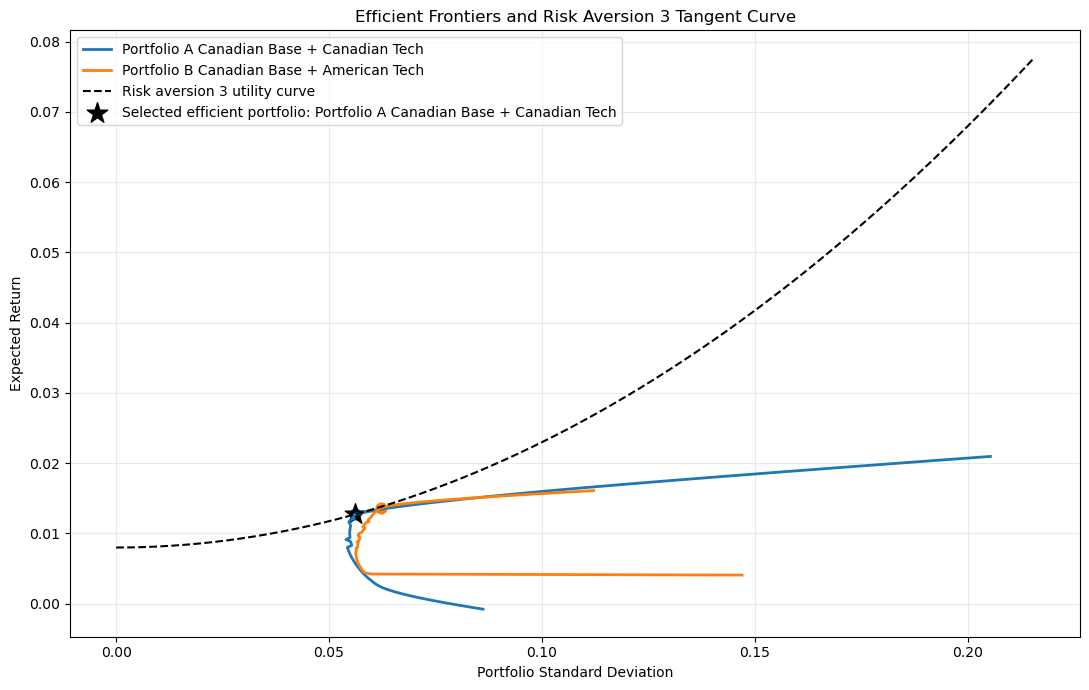

In [50]:
# Plot both efficient frontiers and the risk aversion 3 utility curve.
plt.figure(figsize=(11, 7))

max_stdev = max(np.sqrt(result["frontier_variances"]).max() for result in analysis.values())
x_values = np.linspace(0, max_stdev * 1.05, 200)
selected_utility = selected_result["best_utility"]
tangent_curve = selected_utility + 0.5 * risk_aversion * x_values**2

for name, result in analysis.items():
    frontier_stdev = np.sqrt(result["frontier_variances"])
    plt.plot(
        frontier_stdev,
        result["frontier_returns"],
        linewidth=2,
        label=name,
    )
    plt.scatter(
        np.sqrt(result["best_variance"]),
        result["best_return"],
        s=60,
    )

plt.plot(x_values, tangent_curve, "k--", label="Risk aversion 3 utility curve")
plt.scatter(
    np.sqrt(selected_result["best_variance"]),
    selected_result["best_return"],
    marker="*",
    s=240,
    color="black",
    label=f"Selected efficient portfolio: {selected_name}",
)

plt.xlabel("Portfolio Standard Deviation")
plt.ylabel("Expected Return")
plt.title("Efficient Frontiers and Risk Aversion 3 Tangent Curve")
plt.legend()
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()